# Experiment No. 07

# Decision Trees, Pruning and Overfitting

## AIM

To implement a **Decision Tree Classifier**, study the effect of tree depth on model performance, identify overfitting, and apply **cost-complexity pruning** to obtain a suitable decision tree with a good balance between accuracy and model complexity.

# OBJECTIVES

1. To understand the working principle of a **Decision Tree Classifier**.
2. To understand how a decision tree recursively partitions the dataset.
3. To study **Gini impurity and Entropy** as splitting criteria.
4. To train an unrestricted/deep decision tree.
5. To train a shallow decision tree and compare its performance with the deep tree.
6. To investigate the effect of `max_depth` on training and testing accuracy.
7. To identify **overfitting** using the train-test accuracy gap.
8. To understand the **bias-variance trade-off** in decision trees.
9. To apply **cost-complexity pruning** using `ccp_alpha`.
10. To select a suitable tree depth/pruning configuration based on accuracy and interpretability.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("datasets/Titanic-Dataset.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
print("Missing Values:")
display(df.isnull().sum())

Missing Values:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Remove unnecessary identifier/text columns
X = X.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S



Target:


0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [7]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)

Numerical Features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Features: ['Sex', 'Embarked']


/var/folders/4d/bxl021h50qdcr6z35z1s85hm0000gn/T/ipykernel_18112/4012518532.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (623, 7)
Testing Set: (268, 7)


In [9]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [10]:
deep_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="gini",
        random_state=42
    ))
])

deep_tree.fit(X_train, y_train)

deep_train_pred = deep_tree.predict(X_train)
deep_test_pred = deep_tree.predict(X_test)

deep_train_accuracy = accuracy_score(y_train, deep_train_pred)
deep_test_accuracy = accuracy_score(y_test, deep_test_pred)

print("Unrestricted Decision Tree")
print("Training Accuracy:", deep_train_accuracy)
print("Testing Accuracy:", deep_test_accuracy)
print("Train-Test Gap:", deep_train_accuracy - deep_test_accuracy)

Unrestricted Decision Tree
Training Accuracy: 0.9759229534510433
Testing Accuracy: 0.7574626865671642
Train-Test Gap: 0.2184602668838791


In [11]:
shallow_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="gini",
        max_depth=3,
        random_state=42
    ))
])

shallow_tree.fit(X_train, y_train)

shallow_train_pred = shallow_tree.predict(X_train)
shallow_test_pred = shallow_tree.predict(X_test)

shallow_train_accuracy = accuracy_score(
    y_train,
    shallow_train_pred
)

shallow_test_accuracy = accuracy_score(
    y_test,
    shallow_test_pred
)

print("Shallow Decision Tree (max_depth=3)")
print("Training Accuracy:", shallow_train_accuracy)
print("Testing Accuracy:", shallow_test_accuracy)
print("Train-Test Gap:", shallow_train_accuracy - shallow_test_accuracy)

Shallow Decision Tree (max_depth=3)
Training Accuracy: 0.8298555377207063
Testing Accuracy: 0.7947761194029851
Train-Test Gap: 0.03507941831772121


In [12]:
comparison = pd.DataFrame({
    "Model": [
        "Unrestricted Tree",
        "Shallow Tree (max_depth=3)"
    ],
    "Train Accuracy": [
        deep_train_accuracy,
        shallow_train_accuracy
    ],
    "Test Accuracy": [
        deep_test_accuracy,
        shallow_test_accuracy
    ],
    "Train-Test Gap": [
        deep_train_accuracy - deep_test_accuracy,
        shallow_train_accuracy - shallow_test_accuracy
    ]
})

display(comparison)

,Model,Train Accuracy,Test Accuracy,Train-Test Gap
0,Unrestricted Tree,0.975923,0.757463,0.218460
1,Shallow Tree (max_depth=3),0.829856,0.794776,0.035079


In [13]:
depths = range(1, 15)

train_accuracies = []
test_accuracies = []
accuracy_gaps = []

for depth in depths:

    tree = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            criterion="gini",
            max_depth=depth,
            random_state=42
        ))
    ])

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    accuracy_gaps.append(train_acc - test_acc)

depth_results = pd.DataFrame({
    "Max Depth": list(depths),
    "Train Accuracy": train_accuracies,
    "Test Accuracy": test_accuracies,
    "Train-Test Gap": accuracy_gaps
})

display(depth_results)

,Max Depth,Train Accuracy,Test Accuracy,Train-Test Gap
0,1,0.791332,0.776119,0.015213
1,2,0.807384,0.768657,0.038727
2,3,0.829856,0.794776,0.035079
3,4,0.845907,0.794776,0.051131
4,5,0.863563,0.791045,0.072519
5,6,0.882825,0.791045,0.091780
6,7,0.894061,0.787313,0.106748
7,8,0.916533,0.772388,0.144145
8,9,0.929374,0.783582,0.145792
9,10,0.940610,0.768657,0.171953


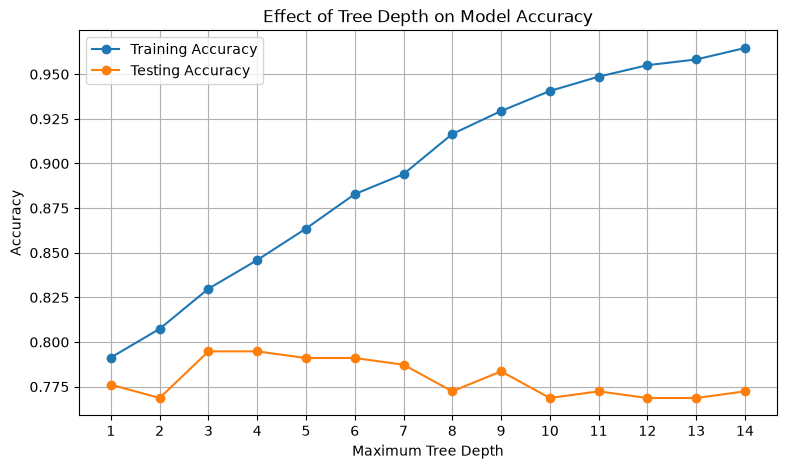

In [14]:
plt.figure(figsize=(9, 5))

plt.plot(
    depths,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depths,
    test_accuracies,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth on Model Accuracy")
plt.xticks(list(depths))
plt.legend()
plt.grid(True)

plt.show()

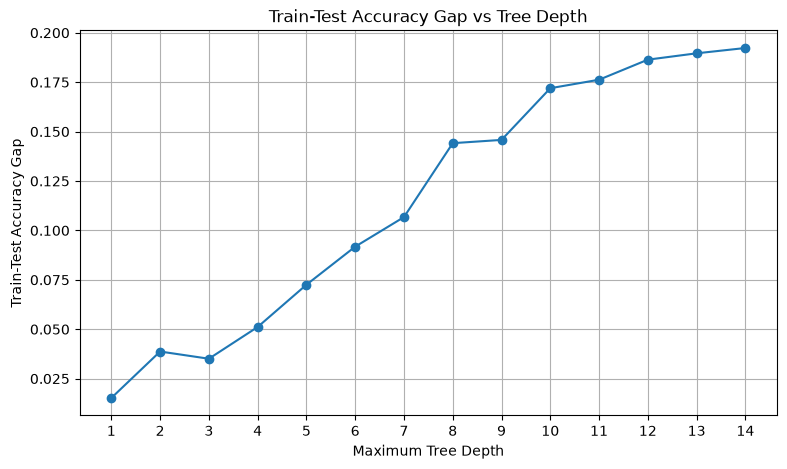

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    depths,
    accuracy_gaps,
    marker="o"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Train-Test Accuracy Gap")
plt.title("Train-Test Accuracy Gap vs Tree Depth")
plt.xticks(list(depths))
plt.grid(True)

plt.show()

In [16]:
# Compare Gini and Entropy

gini_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        random_state=42
    ))
])

entropy_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="entropy",
        max_depth=5,
        random_state=42
    ))
])

gini_tree.fit(X_train, y_train)
entropy_tree.fit(X_train, y_train)

gini_accuracy = accuracy_score(
    y_test,
    gini_tree.predict(X_test)
)

entropy_accuracy = accuracy_score(
    y_test,
    entropy_tree.predict(X_test)
)

criteria_comparison = pd.DataFrame({
    "Criterion": ["Gini", "Entropy"],
    "Test Accuracy": [
        gini_accuracy,
        entropy_accuracy
    ]
})

display(criteria_comparison)

,Criterion,Test Accuracy
0,Gini,0.791045
1,Entropy,0.787313


In [17]:
# Fit preprocessing separately only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Train an unrestricted tree for obtaining pruning path
pruning_tree = DecisionTreeClassifier(
    random_state=42
)

pruning_tree.fit(X_train_processed, y_train)

path = pruning_tree.cost_complexity_pruning_path(
    X_train_processed,
    y_train
)

ccp_alphas = path.ccp_alphas

print("Number of candidate ccp_alpha values:", len(ccp_alphas))
print("Candidate ccp_alpha values:")
print(ccp_alphas)

Number of candidate ccp_alpha values: 68
Candidate ccp_alpha values:
[0.00000000e+00 0.00000000e+00 7.64350684e-05 1.01913425e-04
 1.01913425e-04 1.24843945e-04 1.52870137e-04 4.20392876e-04
 5.15936712e-04 5.73263013e-04 6.95559123e-04 6.95559123e-04
 7.35166385e-04 7.85121083e-04 8.40785753e-04 9.17220821e-04
 9.63081862e-04 9.64625262e-04 1.03442126e-03 1.05480394e-03
 1.07009096e-03 1.07009096e-03 1.15755031e-03 1.19169220e-03
 1.20385233e-03 1.24843945e-03 1.26658719e-03 1.28410915e-03
 1.28410915e-03 1.40258351e-03 1.41508167e-03 1.42678794e-03
 1.43315753e-03 1.48166440e-03 1.54781014e-03 1.61786779e-03
 1.91682166e-03 2.01979668e-03 2.06374685e-03 2.08778796e-03
 2.14018192e-03 2.14018192e-03 2.28005809e-03 2.33348867e-03
 2.40770465e-03 2.40770465e-03 2.47096126e-03 2.51643970e-03
 2.56821830e-03 2.56821830e-03 2.62172285e-03 2.75871690e-03
 2.90708044e-03 2.94275013e-03 3.05411425e-03 3.11299188e-03
 3.21027287e-03 3.24924245e-03 3.82265068e-03 3.93603438e-03
 4.24270667e-03 

In [18]:
# Remove the final alpha because it produces a tree with only one node
ccp_alphas = ccp_alphas[:-1]

pruned_results = []

for alpha in ccp_alphas:

    tree = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )

    tree.fit(X_train_processed, y_train)

    train_pred = tree.predict(X_train_processed)
    test_pred = tree.predict(X_test_processed)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    pruned_results.append({
        "ccp_alpha": alpha,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Train-Test Gap": train_acc - test_acc,
        "Tree Depth": tree.get_depth(),
        "Number of Leaves": tree.get_n_leaves()
    })

pruned_results = pd.DataFrame(pruned_results)

display(pruned_results.head(20))

,ccp_alpha,Train Accuracy,Test Accuracy,Train-Test Gap,Tree Depth,Number of Leaves
0,0.000000,0.975923,0.757463,0.218460,19,145
1,0.000000,0.975923,0.757463,0.218460,19,145
2,0.000076,0.975923,0.757463,0.218460,19,143
3,0.000102,0.975923,0.757463,0.218460,19,142
4,0.000102,0.975923,0.757463,0.218460,19,140
5,0.000125,0.975923,0.757463,0.218460,19,137
6,0.000153,0.975923,0.757463,0.218460,19,136
7,0.000420,0.975923,0.757463,0.218460,19,134
8,0.000516,0.975923,0.757463,0.218460,19,133
9,0.000573,0.975923,0.757463,0.218460,19,131


In [19]:
# Select the alpha with the highest test accuracy
best_row = pruned_results.loc[
    pruned_results["Test Accuracy"].idxmax()
]

best_alpha = best_row["ccp_alpha"]

print("Best ccp_alpha:", best_alpha)
print("Test Accuracy:", best_row["Test Accuracy"])
print("Tree Depth:", best_row["Tree Depth"])
print("Number of Leaves:", best_row["Number of Leaves"])

Best ccp_alpha: 0.002758716903212645
Test Accuracy: 0.8059701492537313
Tree Depth: 8.0
Number of Leaves: 23.0


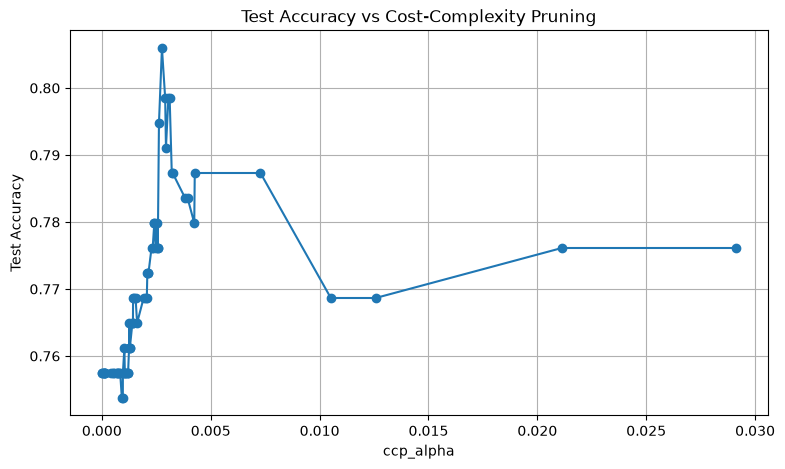

In [20]:
plt.figure(figsize=(9, 5))

plt.plot(
    pruned_results["ccp_alpha"],
    pruned_results["Test Accuracy"],
    marker="o"
)

plt.xlabel("ccp_alpha")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Cost-Complexity Pruning")
plt.grid(True)

plt.show()

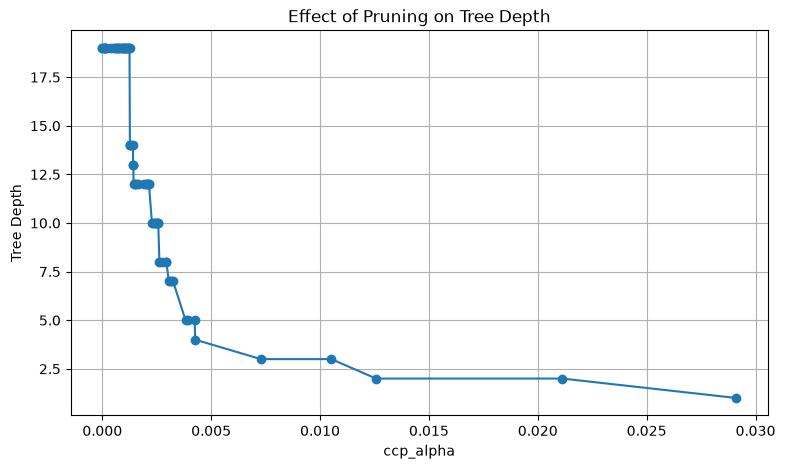

In [21]:
plt.figure(figsize=(9, 5))

plt.plot(
    pruned_results["ccp_alpha"],
    pruned_results["Tree Depth"],
    marker="o"
)

plt.xlabel("ccp_alpha")
plt.ylabel("Tree Depth")
plt.title("Effect of Pruning on Tree Depth")
plt.grid(True)

plt.show()

In [22]:
final_tree = DecisionTreeClassifier(
    criterion="gini",
    ccp_alpha=best_alpha,
    random_state=42
)

final_tree.fit(X_train_processed, y_train)

final_train_pred = final_tree.predict(X_train_processed)
final_test_pred = final_tree.predict(X_test_processed)

final_train_accuracy = accuracy_score(
    y_train,
    final_train_pred
)

final_test_accuracy = accuracy_score(
    y_test,
    final_test_pred
)

print("Final Pruned Decision Tree")
print("ccp_alpha:", best_alpha)
print("Tree Depth:", final_tree.get_depth())
print("Number of Leaves:", final_tree.get_n_leaves())
print("Training Accuracy:", final_train_accuracy)
print("Testing Accuracy:", final_test_accuracy)
print(
    "Train-Test Gap:",
    final_train_accuracy - final_test_accuracy
)

Final Pruned Decision Tree
ccp_alpha: 0.002758716903212645
Tree Depth: 8
Number of Leaves: 23
Training Accuracy: 0.8780096308186196
Testing Accuracy: 0.8059701492537313
Train-Test Gap: 0.07203948156488826


In [23]:
# Final comparison

final_comparison = pd.DataFrame({
    "Model": [
        "Unrestricted Tree",
        "Shallow Tree (Depth=3)",
        "Pruned Tree"
    ],
    "Train Accuracy": [
        deep_train_accuracy,
        shallow_train_accuracy,
        final_train_accuracy
    ],
    "Test Accuracy": [
        deep_test_accuracy,
        shallow_test_accuracy,
        final_test_accuracy
    ],
    "Train-Test Gap": [
        deep_train_accuracy - deep_test_accuracy,
        shallow_train_accuracy - shallow_test_accuracy,
        final_train_accuracy - final_test_accuracy
    ]
})

display(final_comparison)

,Model,Train Accuracy,Test Accuracy,Train-Test Gap
0,Unrestricted Tree,0.975923,0.757463,0.218460
1,Shallow Tree (Depth=3),0.829856,0.794776,0.035079
2,Pruned Tree,0.878010,0.805970,0.072039


# OBSERVATION

- The unrestricted decision tree generally achieved high training accuracy but showed a larger train-test accuracy gap, indicating possible **overfitting**.
- The shallow tree with `max_depth=3` produced a simpler model and generally reduced model complexity.
- As `max_depth` increased, training accuracy generally increased because the tree became more complex.
- Testing accuracy improved initially and may decrease or fluctuate at higher depths due to overfitting.
- The train-test accuracy gap was used to identify increasing variance and possible overfitting.
- Both **Gini impurity** and **Entropy** were investigated as splitting criteria.
- Cost-complexity pruning using `ccp_alpha` reduced unnecessary branches and produced a simpler decision tree.
- The final tree was selected by considering test accuracy, train-test gap, tree depth, and interpretability.

# CONCLUSION

A Decision Tree Classifier was successfully implemented on the Titanic dataset. The effect of tree depth on training and testing accuracy was studied.

The unrestricted tree demonstrated the tendency of highly complex decision trees to overfit the training data. A shallow tree provided a simpler alternative with potentially better generalisation.

The **Gini** and **Entropy** splitting criteria were also compared. Finally, **cost-complexity pruning** was applied using `ccp_alpha` to remove unnecessary branches and control model complexity.

Therefore, an appropriate tree depth or pruning parameter should be selected based on **generalisation performance and interpretability**, rather than training accuracy alone.